In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot

np.random.seed(42)

df = pd.read_csv('sales.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [5]:
df.head()

,sales
date,
2022-01-01,1200
2022-01-02,980
2022-01-03,1100
2022-01-04,870
2022-01-05,760


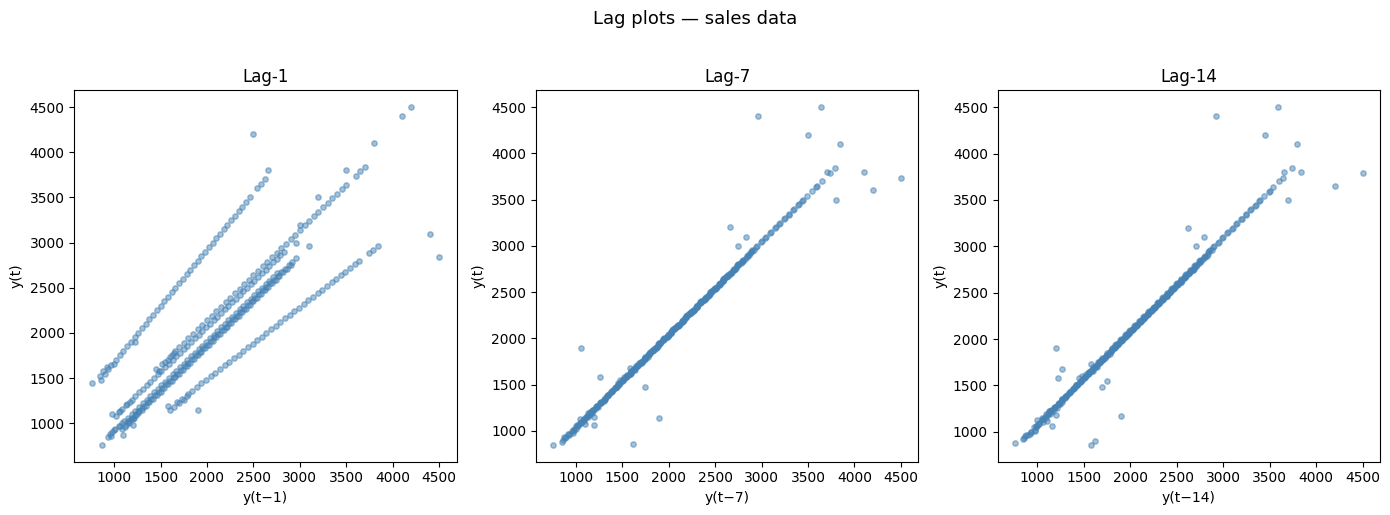

In [4]:
# --- Plot lag 1, 7, 14 side by side ---
lags_to_check = [1, 7, 14]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, k in zip(axes, lags_to_check):
    lag_plot(df['sales'], lag=k, ax=ax, c='steelblue', alpha=0.5, s=15)
    ax.set_title(f'Lag-{k}', fontsize=12)
    ax.set_xlabel(f'y(t−{k})')
    ax.set_ylabel('y(t)')

plt.suptitle('Lag plots — sales data', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('lag_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Lag plots

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot

In [7]:
np.random.seed(42)
n = 365 * 2
dates = pd.date_range("2021-01-01", periods=n, freq="D")

In [8]:
# Series A: Strong Trend (Non-stationary)
trend = np.linspace(100, 200, n)
sales_trend = trend + np.random.normal(0, 3, n)

In [9]:
# Series B: Weekly Seasonality (Stationary around mean)
daily_pattern = np.array([80, 85, 90, 95, 100, 130, 120])
seasonal = np.tile(daily_pattern, n // 7 + 1)[:n]
sales_seasonal = seasonal + np.random.normal(0, 4, n)

In [10]:
# --- Series C: Pure White Noise (No memory) ---
sales_random = np.random.normal(100, 10, n)

In [11]:
# Create DataFrame
df = pd.DataFrame({
    'date': dates,
    'trend': sales_trend,
    'seasonal': sales_seasonal,
    'random': sales_random
})
df.set_index('date', inplace=True)

In [12]:
df.head()

,trend,seasonal,random
date,,,
2021-01-01,101.490142,80.783381,98.615440
2021-01-02,99.722381,81.086509,87.757018
2021-01-03,102.217414,91.633011,97.909767
2021-01-04,104.980612,88.189666,91.494795
2021-01-05,99.846237,104.116623,94.194766


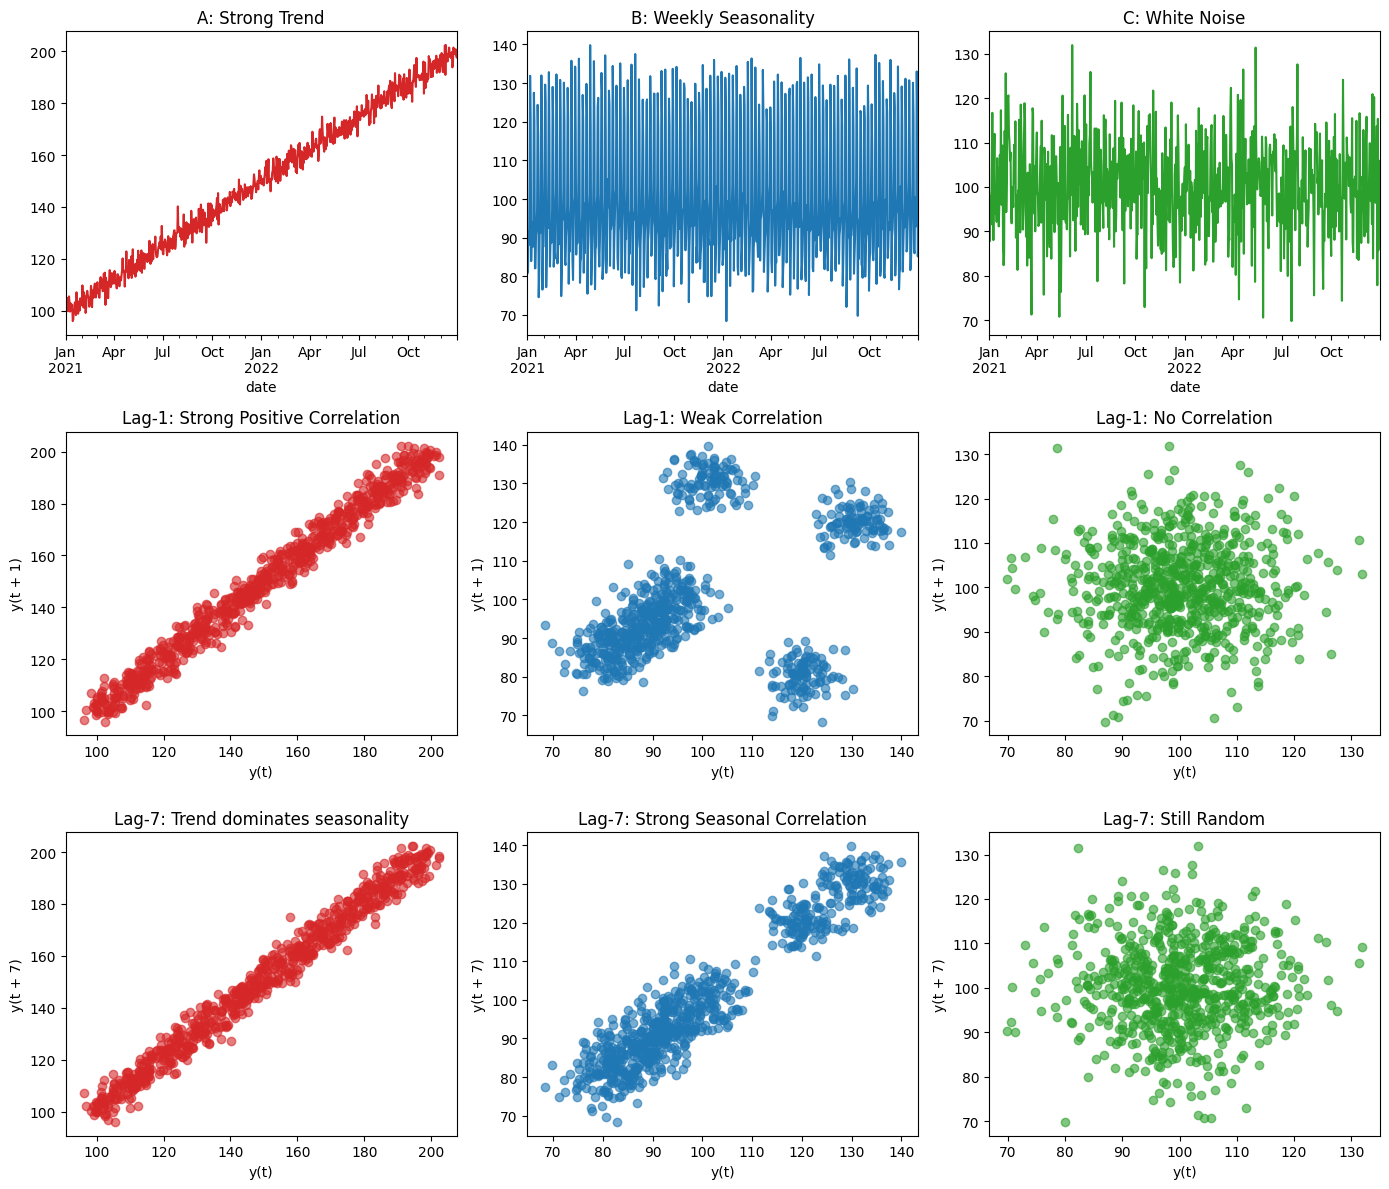

In [13]:
# Plotting
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

# Row 1: Time series plots
df['trend'].plot(ax=axes[0,0], title="A: Strong Trend", color='tab:red')
df['seasonal'].plot(ax=axes[0,1], title="B: Weekly Seasonality", color='tab:blue')
df['random'].plot(ax=axes[0,2], title="C: White Noise", color='tab:green')

# Row 2: Lag-1 plots
lag_plot(df['trend'], lag=1, ax=axes[1,0], c='tab:red', alpha=0.6)
axes[1,0].set_title("Lag-1: Strong Positive Correlation")
lag_plot(df['seasonal'], lag=1, ax=axes[1,1], c='tab:blue', alpha=0.6)
axes[1,1].set_title("Lag-1: Weak Correlation")
lag_plot(df['random'], lag=1, ax=axes[1,2], c='tab:green', alpha=0.6)
axes[1,2].set_title("Lag-1: No Correlation")

# Row 3: Lag-7 plots (weekly)
lag_plot(df['trend'], lag=7, ax=axes[2,0], c='tab:red', alpha=0.6)
axes[2,0].set_title("Lag-7: Trend dominates seasonality")
lag_plot(df['seasonal'], lag=7, ax=axes[2,1], c='tab:blue', alpha=0.6)
axes[2,1].set_title("Lag-7: Strong Seasonal Correlation")
lag_plot(df['random'], lag=7, ax=axes[2,2], c='tab:green', alpha=0.6)
axes[2,2].set_title("Lag-7: Still Random")

plt.tight_layout()
plt.show()